# 03 · Backtest de producción — holdout final de 30 días
**¿Cómo se vería el modelo en producción, medido contra 30 días de demanda real?**

Este notebook ejecuta un experimento de una sola pregunta: **apartamos los últimos 30 días del dataset (31 ene – 29 feb 2024), entrenamos la última versión del modelo con todo lo anterior, y el modelo no ve esos 30 días para nada** — ni en el entrenamiento ni en las features de los días que pronostica. Luego emite el pronóstico de esos 30 días de una sola vez (como haría en producción el día del corte) y lo confrontamos con la demanda real apartada.

Diferencia con el walk-forward del notebook 02: aquí los días de prueba se **eliminan físicamente** de las transacciones antes de construir features (igual que en producción, donde el futuro no existe), así que ninguna estadística puede tocarlos ni por error. Es la prueba más cercana a "puesta en producción" que se puede hacer con datos históricos.

> El motor es `src.holdout.run_holdout` — la misma función probada del pipeline (`retail-holdout`), aquí invocada con un corte de 30 días. El notebook solo orquesta y visualiza; no reimplementa lógica.

**Nota metodológica importante:** el modelo se diseñó para un horizonte de **14 días**. Pronosticar 30 días de una sola emisión empuja la segunda mitad *más allá* de ese horizonte: para los días lejanos, los rezagos de demanda de 14/21/28 días caen dentro del propio holdout y no existen. El modelo lo maneja de forma nativa (apoyándose en calendario y atributos de tienda), pero **este es justo el estrés que el backtest busca exponer** — y como veremos, la degradación fuera del horizonte de diseño es suficiente para que el modelo pierda su ventaja. Es un resultado deseado del ejercicio, no un defecto oculto.

In [1]:
import sys, warnings
sys.path.append("..")

import numpy as np
import pandas as pd
import plotly.graph_objects as go

from src import config, viz
from src.preprocesamiento.data import load_transactions, load_stores, load_calendar
from src.evaluacion.holdout import run_holdout, summarize_holdout, summarize_holdout_paired
from src.evaluacion.metrics import evaluate

warnings.filterwarnings("ignore")
viz.apply_plotly_style()   # tema 'retail' + renderer interactivo con fallback PNG

HOLDOUT_DIAS = 30
tx, stores, cal = load_transactions(), load_stores(), load_calendar()
cutoff = tx["date"].max() - pd.Timedelta(days=HOLDOUT_DIAS)
print(f"Corte de entrenamiento: {cutoff.date()}  "
      f"(el modelo NO ve nada posterior)")
print(f"Ventana de backtest:   {(cutoff + pd.Timedelta(days=1)).date()} → {tx['date'].max().date()}"
      f"  ({HOLDOUT_DIAS} días)")

Corte de entrenamiento: 2024-01-30  (el modelo NO ve nada posterior)
Ventana de backtest:   2024-01-31 → 2024-02-29  (30 días)


In [2]:
# Entrena con datos <= cutoff y pronostica los 30 días apartados (1 emisión).
preds = run_holdout(tx, stores, cal, cutoff)
preds = preds.merge(stores[["store_id", "store_format"]], on="store_id")

MODEL_COLORS = {
    "real": viz.INK,
    "gradient_boosting_prior": "#2a78d6",
    "sistema_actual": "#e34948",
    "naive_estacional": "#eda100",
}
MODEL_LABELS = {
    "gradient_boosting_prior": "Modelo propuesto",
    "sistema_actual": "Sistema actual",
    "naive_estacional": "Naïve estacional",
}
CAMPEON = "gradient_boosting_prior"
print(f"{preds['date'].nunique()} días × {preds[['store_id','category']].drop_duplicates().shape[0]} series "
      f"× {preds['modelo'].nunique()} modelos = {len(preds):,} predicciones")

30 días × 480 series × 4 modelos = 57,600 predicciones


## 1 · Métricas globales

Cada WAPE lleva su **IC 95%** por bootstrap de bloques de fecha (se remuestrean días completos). La fila de significancia es la prueba **pareada**: el campeón le gana a un rival solo si el IC de la diferencia de WAPE no cruza cero.

In [3]:
met = summarize_holdout(preds)
tabla = met[met["tramo"] == "total"].set_index("modelo")
resumen = pd.DataFrame({
    "WAPE": tabla["wape"].round(3),
    "IC 95%": [f"[{lo:.3f}, {hi:.3f}]" for lo, hi in zip(tabla["wape_lo"], tabla["wape_hi"])],
    "MAE": tabla["mae"].round(0),
    "Sesgo": tabla["bias"].round(3),
}).reindex(["gradient_boosting_prior", "sistema_actual", "naive_estacional"])
resumen.index = [MODEL_LABELS[m] for m in resumen.index]
print("Desempeño sobre los 30 días apartados:\n")
print(resumen.to_string())

print("\nΔWAPE pareado (campeón − rival; negativo = campeón mejor):")
print(summarize_holdout_paired(preds).round(3).to_string(index=False))

Desempeño sobre los 30 días apartados:

                   WAPE          IC 95%    MAE  Sesgo
Modelo propuesto  0.307  [0.291, 0.322]  310.0 -0.229
Sistema actual    0.297  [0.271, 0.332]  300.0 -0.003
Naïve estacional  0.287  [0.272, 0.307]  290.0 -0.040

ΔWAPE pareado (campeón − rival; negativo = campeón mejor):
                               comparacion delta_wape  delta_lo  delta_hi significativo n_dias
  gradient_boosting_prior − sistema_actual   0.009696 -0.032005  0.040211         False     30
gradient_boosting_prior − naive_estacional    0.01965 -0.003521  0.037193         False     30


## 2 · ¿Se degrada la precisión conforme nos alejamos del corte?

Segmentamos por *distancia al corte* en tres tramos de 10 días. El primer tramo (días 1–10) está dentro del horizonte de diseño; el tercero (días 21–30) opera casi sin rezagos de demanda, apoyado en calendario y atributos.

In [4]:
preds["dias_desde_corte"] = (preds["date"] - cutoff).dt.days
preds["horizonte"] = pd.cut(preds["dias_desde_corte"], [0, 10, 20, 30],
                            labels=["días 1-10", "días 11-20", "días 21-30"])

camp = preds[preds["modelo"] == CAMPEON]
por_horizonte = evaluate(camp, by=["horizonte"])[["horizonte", "n", "wape", "mae", "bias"]]
print("Modelo propuesto, por tramo de horizonte:")
print(por_horizonte.round(3).to_string(index=False))

Modelo propuesto, por tramo de horizonte:
 horizonte    n  wape     mae   bias
 días 1-10 4647 0.257 250.585 -0.118
días 11-20 4658 0.335 358.036 -0.294
días 21-30 4643 0.326 322.032 -0.268


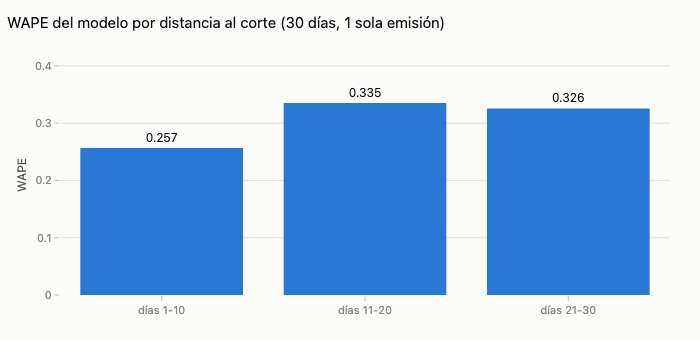

In [5]:
fig = go.Figure()
h = evaluate(camp, by=["horizonte"])
fig.add_bar(x=h["horizonte"].astype(str), y=h["wape"], marker_color=viz.ACCENT,
            text=[f"{v:.3f}" for v in h["wape"]], textposition="outside",
            hovertemplate="%{x}: WAPE <b>%{y:.3f}</b><extra></extra>")
fig.update_layout(title="WAPE del modelo por distancia al corte (30 días, 1 sola emisión)",
                  yaxis_title="WAPE", height=340, showlegend=False)
fig.update_yaxes(range=[0, h["wape"].max() * 1.25])
fig.show()

## 3 · La salida, día a día

Serie de tiempo de la venta agregada de la cadena en los 30 días apartados: la línea negra es la demanda **real**, las de color son lo que cada modelo pronosticó. *Pasa el cursor para ver los valores exactos; arrastra para hacer zoom.* (En GitHub se muestra la versión estática.)

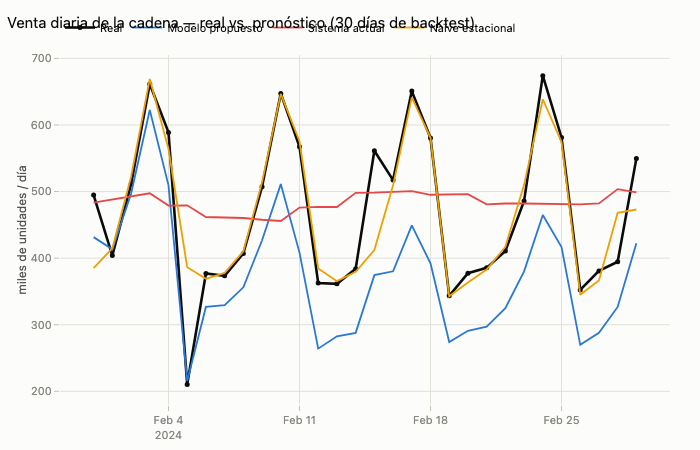

In [6]:
fechas = pd.date_range(preds["date"].min(), preds["date"].max(), freq="D")
# Fechas como strings ISO: plotly las trata como eje de fecha y kaleido
# (serializador orjson) las exporta a PNG sin problema con Timestamps.
fechas_x = [d.strftime("%Y-%m-%d") for d in fechas]

def serie_cadena(df, modelo, valor):
    s = df[df["modelo"] == modelo].groupby("date")[valor].sum() / 1e3
    return s.reindex(fechas).to_numpy()

fig = go.Figure()
fig.add_scatter(x=fechas_x, y=serie_cadena(preds, CAMPEON, "y_true"),
                mode="lines+markers", name="Real",
                line=dict(color=MODEL_COLORS["real"], width=2.6),
                marker=dict(size=5),
                hovertemplate="%{x|%a %d %b}<br>Real: <b>%{y:.0f}k uds</b><extra></extra>")
for modelo in ["gradient_boosting_prior", "sistema_actual", "naive_estacional"]:
    fig.add_scatter(x=fechas_x, y=serie_cadena(preds, modelo, "y_pred"),
                    mode="lines", name=MODEL_LABELS[modelo],
                    line=dict(color=MODEL_COLORS[modelo], width=1.8),
                    hovertemplate="%{x|%a %d %b}<br>" + MODEL_LABELS[modelo]
                                  + ": <b>%{y:.0f}k uds</b><extra></extra>")
fig.update_layout(title="Venta diaria de la cadena — real vs. pronóstico (30 días de backtest)",
                  yaxis_title="miles de unidades / día", height=450,
                  hovermode="x unified",
                  legend=dict(orientation="h", y=1.12, font=dict(size=11)))
fig.show()

### 3.1 · Una serie individual, para ver el ajuste fino

La agregación de la cadena suaviza el error. Veamos una sola serie tienda × categoría de alto volumen para juzgar el ajuste a nivel operativo (que es donde se decide la reposición).

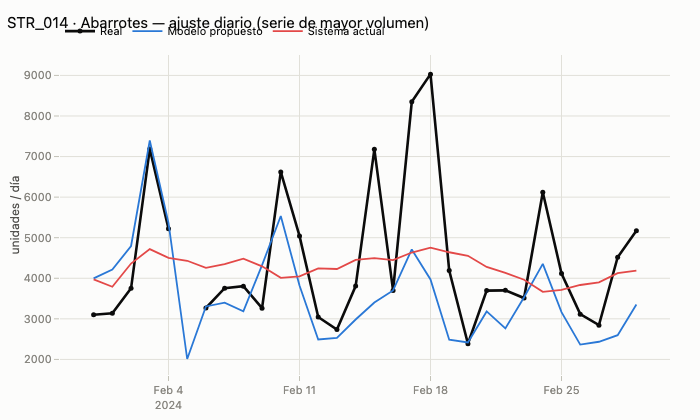

In [7]:
vol = camp.groupby(["store_id", "category"], observed=True)["y_true"].sum()
sid, cat = vol.idxmax()
una = preds[(preds["store_id"] == sid) & (preds["category"] == cat)]

c = una[una.modelo == CAMPEON].sort_values("date")
fig = go.Figure()
fig.add_scatter(x=c["date"].dt.strftime("%Y-%m-%d"), y=c["y_true"],
                mode="lines+markers", name="Real",
                line=dict(color=MODEL_COLORS["real"], width=2.6), marker=dict(size=5),
                hovertemplate="%{x|%a %d %b}<br>Real: <b>%{y:.0f} uds</b><extra></extra>")
for modelo in ["gradient_boosting_prior", "sistema_actual"]:
    d = una[una.modelo == modelo].sort_values("date")
    fig.add_scatter(x=d["date"].dt.strftime("%Y-%m-%d"), y=d["y_pred"],
                    mode="lines", name=MODEL_LABELS[modelo],
                    line=dict(color=MODEL_COLORS[modelo], width=1.8),
                    hovertemplate="%{x|%a %d %b}<br>" + MODEL_LABELS[modelo]
                                  + ": <b>%{y:.0f} uds</b><extra></extra>")
fig.update_layout(title=f"{sid} · {cat} — ajuste diario (serie de mayor volumen)",
                  yaxis_title="unidades / día", height=420, hovermode="x unified",
                  legend=dict(orientation="h", y=1.12, font=dict(size=11)))
fig.show()

## 4 · Lectura — el hallazgo clave: el modelo tiene un *horizonte útil*

Este backtest expone algo que el walk-forward del notebook 02 (a 14 días) no podía: **qué pasa cuando se estira el modelo más allá de su horizonte de diseño.** El resultado, por tramo:

| Tramo | Modelo propuesto | Sistema actual | Naïve estacional |
|---|---|---|---|
| días 1–10 | **0.257** ✓ | 0.306 | 0.284 |
| días 11–20 | 0.335 | 0.299 | **0.277** |
| días 21–30 | 0.326 | **0.286** | 0.301 |
| **30 días** | 0.307 | 0.297 | **0.287** |

- **Dentro de su horizonte de diseño (días 1–10), el modelo es el mejor** — le gana a ambos baselines, consistente con todo lo visto en el notebook 02.
- **Fuera de él (días 11–30), el modelo pierde su ventaja y cae por debajo de los baselines.** El mecanismo es visible en la gráfica de la sección 3: la línea azul **sub-predice los picos semanales** cada vez más hacia la derecha. La causa es concreta — para esos días los rezagos de demanda (14/21/28) caen dentro del holdout y no existen; el modelo, entrenado para apoyarse en ellos, regresa hacia un nivel bajo (sesgo −0.29 en días 11–30) en vez de reconstruir la amplitud de los picos.
- **Por qué el naïve aguanta mejor a la distancia:** su pronóstico es el promedio del mismo día de la semana de hace 2–4 semanas (con respaldo en la media móvil de finales de enero). Para una serie de estacionalidad semanal estable, ese nivel es un estimador fuerte que **no se degrada con el horizonte** — por eso es tan difícil de vencer lejos del corte.
- El sistema actual es plano (~490k/día): ignora la estructura semanal, pero al no depender de rezagos tampoco colapsa.
- Ventana sin Buen Fin ni Navidad → el prior de eventos es neutro y las dos variantes del campeón coinciden; este backtest mide el desempeño *base* fuera de picos.

**La conclusión operativa (el valor de este ejercicio):** el modelo **no** debe emitirse en un solo disparo a 30 días. Es una herramienta de horizonte ~14 días, y su modo de uso correcto en producción es **re-emisión con origen rodante cada 1–2 semanas**: al reentrenar y re-pronosticar con más frecuencia, los rezagos de demanda se mantienen frescos y la ventana útil nunca se agota. Este backtest cuantifica el costo de dejar "envejecer" los rezagos y, con ello, **define la cadencia de re-emisión** — un parámetro operativo que hay que fijar, no un detalle. También valida empíricamente la elección de `HORIZON=14` como el alcance donde el modelo aporta valor sobre alternativas más simples.